# 01 - Run Experiments (self-contained)

Controlled 80-episode LIBERO slice + LIBERO-PRO 600-episode stretch for **pi0.5** and **SmolVLA**, with the **RNG-isolation fix** applied to the P&P sampler.

**Outputs:** `rollouts_final.db` (slice), `rollouts_pro.db` (PRO), and `ahats/*.npz` (raw per-iteration clean-action stacks for the geometry analyses in notebook 03).

> Requires a GPU, the LIBERO/MuJoCo simulator, and gated pi0.5/SmolVLA checkpoints (set `HF_TOKEN`). Run top to bottom.

## 1. Config

In [11]:
# === Unified config: single Drive root, one schema per artifact =============
import os

try:
    from google.colab import drive
    drive.mount('/content/drive')
    DRIVE = '/content/drive/MyDrive'
except Exception:
    DRIVE = os.path.expanduser('~')

FINAL_ROOT  = os.path.join(DRIVE, 'cs159-sp26-final')
RESULTS_DIR = os.path.join(FINAL_ROOT, 'results')
VIDEO_DIR   = os.path.join(RESULTS_DIR, 'videos')
AHATS_DIR   = os.path.join(RESULTS_DIR, 'ahats')      # raw a_hats stacks (geometry)
FIGURES_DIR = os.path.join(FINAL_ROOT, 'figures')
TABLES_DIR  = os.path.join(FINAL_ROOT, 'tables')

SLICE_DB = os.path.join(RESULTS_DIR, 'rollouts_libero_final_23.db')  # controlled 80-ep slice
# PRO_DB   = os.path.join(RESULTS_DIR, 'rollouts_pro.db')    # LIBERO-PRO 600-ep
QC_DB    = os.path.join(RESULTS_DIR, 'qc.db')              # PCP chunks + 3-way eval
QC_CKPT  = os.path.join(RESULTS_DIR, 'q_corrector.pt')

# Curated LIBERO-PRO init files (.pruned_init) must be placed here by the user
# (exported from the LIBERO-Pro dataset). See the LIBERO-PRO markdown cell.
PRO_INIT_SRC = os.path.join(FINAL_ROOT, 'libero_pro_init_files')

# Optional package snapshot tarball (speeds up Colab restore).
CACHE_DIR = os.path.join(DRIVE, 'smolvla_colab_cache')

for _d in (RESULTS_DIR, VIDEO_DIR, AHATS_DIR, FIGURES_DIR, TABLES_DIR):
    os.makedirs(_d, exist_ok=True)

MODELS = ['pi05'] #, 'smolvla']
print('FINAL_ROOT =', FINAL_ROOT)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
FINAL_ROOT = /content/drive/MyDrive/cs159-sp26-final


## 2. Environment

In [2]:
import torch.ao.quantization as _q
for _name in ('CUSTOM_KEY', 'NUMERIC_DEBUG_HANDLE_KEY', 'FROM_NODE_KEY'):
    if not hasattr(_q, _name):
        setattr(_q, _name, _name.lower())
        print(f'patched torch.ao.quantization.{_name}')

patched torch.ao.quantization.FROM_NODE_KEY


In [3]:
# === Environment: GPU + LIBERO/MuJoCo + lerobot (pi0.5 & SmolVLA) ===========
import subprocess, sys, os, importlib

print(subprocess.run(['nvidia-smi', '--query-gpu=name,memory.total',
                      '--format=csv,noheader'], capture_output=True, text=True).stdout.strip()
      or 'No GPU detected (CPU mode will be extremely slow / infeasible).')

# Fast path: restore a prebuilt site-packages snapshot from Drive if present.
SNAPSHOT = os.path.join(CACHE_DIR, 'site_packages.tar.gz')
if os.path.exists(SNAPSHOT):
    import shutil
    local = '/content/site_packages_restore.tar.gz'
    shutil.copy(SNAPSHOT, local)
    subprocess.run(['tar', '-xzf', local, '-C', '/'], check=True)
    os.remove(local)
    importlib.invalidate_caches()
    print('Restored package snapshot.')

os.environ.setdefault('MUJOCO_GL', 'egl')
os.environ.setdefault('TOKENIZERS_PARALLELISM', 'false')
os.environ.setdefault('HF_HOME', os.path.join(CACHE_DIR, 'hf_models'))

def _ensure(mod, pip_spec):
    try:
        importlib.import_module(mod)
    except Exception:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *pip_spec.split()])
        importlib.invalidate_caches()

def _fix_torch_quant_compat():
    # lerobot/diffusers expect torch.ao.quantization.CUSTOM_KEY (torch >= 2.6).
    # Colab's base torch can be older than the restored snapshot expects, which
    # surfaces as: ImportError: cannot import name 'CUSTOM_KEY'. Repair before
    # any lerobot import (which transitively pulls torch.ao.quantization.fx).
    #
    # Probe the *installed metadata* first so we don't import torch (and lock its
    # C extension) unless the version is already adequate. torch is backed by a C
    # extension (torch._C) that CANNOT be re-initialised within a live process:
    # deleting torch from sys.modules and re-importing re-runs torch/overrides.py,
    # whose _add_docstr() calls then fail on already-documented C functions with
    #   RuntimeError: function '_has_torch_function' already has a docstring.
    import importlib.metadata as _md

    def _torch_ge_26():
        try:
            major, minor = (int(x) for x in _md.version('torch').split('.')[:2])
            return (major, minor) >= (2, 6)
        except Exception:
            return False

    if _torch_ge_26():
        import torch
        from torch.ao.quantization import CUSTOM_KEY  # noqa: F401
        print(f'torch {torch.__version__} — quantization compat OK')
        return

    print('torch/quantization mismatch — upgrading torch (CUDA wheels)...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', '-U',
                           'torch', 'torchvision', 'torchaudio'])
    importlib.invalidate_caches()

    # If torch was already imported in this process (e.g. transitively by an
    # earlier import), the C extension is locked and the new build cannot be
    # hot-swapped. The only safe repair is to restart the runtime; Colab
    # auto-restarts, then you re-run this cell with the upgraded torch in place.
    if any(m == 'torch' or m.startswith('torch.') for m in sys.modules):
        print('torch upgraded — restarting runtime to load the new build. '
              'Re-run this cell after the restart.')
        sys.stdout.flush()
        os.kill(os.getpid(), 9)

    # torch was never imported in this process, so a fresh import is safe.
    import torch
    from torch.ao.quantization import CUSTOM_KEY  # noqa: F401
    print(f'torch upgraded to {torch.__version__} — quantization compat OK')

_ensure('mujoco', 'mujoco')
_ensure('libero', 'libero')
_fix_torch_quant_compat()
try:
    from lerobot.policies.pi05.modeling_pi05 import PI05Policy  # noqa: F401
    from lerobot.policies.smolvla.modeling_smolvla import SmolVLAPolicy  # noqa: F401
except Exception:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'lerobot[pi0,smolvla]'])
    importlib.invalidate_caches()

# Authenticate for gated checkpoints (set HF_TOKEN env var beforehand).
from huggingface_hub import login
_tok = os.getenv('HF_TOKEN')
login(token=_tok) if _tok else None
print('Environment ready.')


NVIDIA RTX PRO 6000 Blackwell Server Edition, 97887 MiB
torch 2.10.0+cu128 — quantization compat OK
Environment ready.


## 3. P&P core (RNG-isolated) + RolloutDB + rollout helpers

Self-contained copy of the evaluation core with `torch.randn_like` replaced by a dedicated `torch.Generator` (see the RNG-ISOLATION FIX block) and `a_hats` persistence wired into `RolloutDB.log_episode`.

In [14]:
"""SmolVLA LIBERO eval core — shared by test_smolvla_jennifer.ipynb and test_smolvla_full_run.ipynb."""
import os
import math
import time
import json
import types
import hashlib
import sqlite3
import imageio
from dataclasses import dataclass
from typing import Optional, Sequence

import numpy as np
import torch

# Notebook/runtime globals set by init_session()
device = None
preprocess = None
postprocess = None
# VIDEO_DIR = None
CURRENT_POLICY_MODEL = None
benchmark_dict = None

from libero.libero import benchmark, get_libero_path
from libero.libero.envs import OffScreenRenderEnv
from lerobot.policies.factory import make_pre_post_processors

MAX_STEPS_MAP = {
    'libero_spatial': 220, 'libero_object': 280, 'libero_goal': 300,
    'libero_10': 520, 'libero_90': 400,
}
CAMERAS = ['agentview', 'robot0_eye_in_hand']
IMG_SIZE = 360
LIBERO_DUMMY_ACTION = [0.0] * 6 + [-1.0]
NUM_STEPS_WAIT = 10


def _quat2axisangle(quat):
    if quat[3] > 1.0:
        quat[3] = 1.0
    elif quat[3] < -1.0:
        quat[3] = -1.0
    den = np.sqrt(1.0 - quat[3] * quat[3])
    if math.isclose(den, 0.0):
        return np.zeros(3)
    return (quat[:3] * 2.0 * math.acos(quat[3])) / den


def obs_to_policy(obs_dict, task_desc, device_):
    agentview = np.ascontiguousarray(obs_dict['agentview_image'][::-1, ::-1])
    wrist = np.ascontiguousarray(obs_dict['robot0_eye_in_hand_image'][::-1, ::-1])
    img_agent = torch.from_numpy(agentview / 255.0).permute(2, 0, 1).float()
    img_wrist = torch.from_numpy(wrist / 255.0).permute(2, 0, 1).float()
    state = np.concatenate([
        obs_dict['robot0_eef_pos'],
        _quat2axisangle(obs_dict['robot0_eef_quat']),
        obs_dict['robot0_gripper_qpos'],
    ])
    return {
        'observation.images.image': img_agent,
        'observation.images.image2': img_wrist,
        'observation.state': torch.from_numpy(state).float(),
        'task': task_desc,
    }


def init_libero_benchmark(hf_login=True):
    global device, benchmark_dict
    from huggingface_hub import login
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    hf_token = os.getenv('HF_TOKEN')
    if hf_login:
        login(token=hf_token) if hf_token else login()
    benchmark_dict = benchmark.get_benchmark_dict()
    print(f'LIBERO ready on {device}')
    return device

# ── Predict-and-Perturb (P&P) sampler: config, recorder, patched Euler loop ──
import torch, numpy as np
from dataclasses import dataclass
from typing import Optional, Sequence
from lerobot.policies.pi05.modeling_pi05 import make_att_2d_masks


@dataclass
class PnPConfig:
    """Self-refining (Predict-and-Perturb) sampling config for Pi0.5 flow matching.

    LeRobot time runs s=1.0 (noise) -> s=0.0 (clean), so the paper's early/high-noise
    steps are the FIRST Euler steps (large s). Select them with step_indices=(1,)/(1,2)
    or time_min=0.8.

    NOTE on step 0 (s=1.0): the perturb (1-s)*a_hat + s*eps drops a_hat entirely and returns
    fresh noise. So REFINEMENT at s=1.0 is a no-op-like reseed (the map x->eps has no
    contraction). But UNCERTAINTY at s=1.0 is meaningful: each iteration predicts a_hat from
    an independent noise draw, so U measures the spread of the policy's one-shot action
    prediction over the noise prior (overall predictive variance given the observation).
    Default selection starts at step 1 so the *refinement* demo is non-trivial; step 0 is fine
    and informative for mode="uncertainty".
    """
    enabled: bool = False
    step_indices: Optional[Sequence[int]] = (1,)   # which Euler steps run P&P (ignored if time_min set)
    time_min: Optional[float] = None               # alt selector: run P&P when s >= time_min
    num_iterations: int = 3                         # K predict-and-perturb iterations
    mode: str = "both"                              # "uncertainty" | "refine" | "both"
    action_dim: int = 7                             # real (un-padded) action dims used for uncertainty
    record_per_iteration: bool = False              # also store the full (K,B,chunk,adim) a_hat stack per step

    def step_selected(self, step: int, s: float) -> bool:
        if not self.enabled:
            return False
        if self.time_min is not None:
            return s >= self.time_min
        return self.step_indices is not None and step in tuple(self.step_indices)

    @property
    def do_refine(self) -> bool:
        return self.mode in ("refine", "both")


class PnPRecorder:
    """Collects per-episode P&P uncertainty so it can later be correlated with outcomes.

    After a run, `episodes` is a list of dicts:
        {"meta": {...}, "success": bool, "n_steps": int,
         "chunks": [ {"num_steps": int,
                      "steps": [ {"step": i, "s": float,
                                  "u_consecutive": np[B,chunk,adim],  # Eq.10 mean|Δâ|
                                  "a_std": np[B,chunk,adim],          # spread of â over iters
                                  "u_mean", "u_max", "a_std_mean": float,
                                  "u_vec": np[adim],     # per-action-dim mean of u_consecutive
                                  "a_std_vec": np[adim], # per-action-dim mean of a_std
                                  # only if cfg.record_per_iteration:
                                  "a_hats": np[K,B,chunk,adim]}, ... ]}, ... ]}
    One "chunk" == one full action-chunk prediction (one sample_actions call).
    Action dims (LIBERO): 0-2 = xyz pos, 3-5 = axis-angle rot, 6 = gripper.
    """
    def __init__(self):
        self.reset()

    def reset(self):
        self.episodes = []
        self._cur = None

    def new_episode(self, meta=None):
        self._cur = {"meta": dict(meta or {}), "chunks": [], "success": None, "n_steps": None}

    def log_chunk(self, chunk_rec):
        if self._cur is not None:
            self._cur["chunks"].append(chunk_rec)

    def close_episode(self, success, n_steps):
        if self._cur is None:
            return
        self._cur["success"] = bool(success)
        self._cur["n_steps"] = int(n_steps)
        self.episodes.append(self._cur)
        self._cur = None


# Global handles (notebook-style); the patched method reads these each call.
PNP_CONFIG = PnPConfig()
PNP_RECORDER = PnPRecorder()

# v2: optional inference-step override for matched-compute baselines
INFERENCE_NUM_STEPS_OVERRIDE = None


FINAL_STEP_CONFIGS = [(2, 3), (3, 4), (4, 5)]
PNP_K = 3
BASELINE_STEPS = 10


# === RNG-ISOLATION FIX (addresses 6/19 PDF section 1.1) ======================
# Perturbation noise now uses a dedicated per-device torch.Generator that NEVER
# touches the global RNG. This makes mode="uncertainty" a TRUE full-rollout
# no-op (its executed trajectory is identical to vanilla on the same seed) and
# makes mode="both"/refine perturbations reproducible and paired across methods.
# The old code used torch.randn_like(x_acc), which advanced the global RNG and
# silently desynchronised uncertainty/refinement rollouts from vanilla after the
# first chunk -- the bug the 6/19 report claimed (but did not actually) fix.
_PNP_GENS = {}
_PNP_LAST_SEED = [0]


def _pnp_gen(device):
    d = torch.device(device)
    g = _PNP_GENS.get(d)
    if g is None:
        g = torch.Generator(device=d)
        g.manual_seed(int(_PNP_LAST_SEED[0]) ^ 0x9E3779B9)
        _PNP_GENS[d] = g
    return g


def _pnp_seed_perturb(seed):
    """Seed the dedicated perturbation stream (independent of the global RNG)."""
    _PNP_LAST_SEED[0] = int(seed)
    for g in _PNP_GENS.values():
        g.manual_seed(int(seed) ^ 0x9E3779B9)


# a_hats persistence for the geometry analyses (PCA isotropy / multimodality).
if 'AHATS_DIR' not in dir():
    AHATS_DIR = None


def _save_ahats_npz(rollout_id, all_step_recs):
    """Persist raw per-iteration clean-action stacks when record_per_iteration is on."""
    if AHATS_DIR is None or rollout_id is None:
        return
    arrs = {}
    for ci, st in all_step_recs:
        a = st.get('a_hats')
        if a is not None:
            arrs[f'chunk{ci}_step{st["step"]}'] = np.asarray(a, dtype=np.float32)
    if arrs:
        os.makedirs(AHATS_DIR, exist_ok=True)
        np.savez_compressed(os.path.join(AHATS_DIR, f'{rollout_id}.npz'), **arrs)


def assert_pnp_noop(policy, batch, step_indices=(1, 2), seed=0, raise_on_fail=True):
    """No-op verification for mode="uncertainty" (NON-empty step_indices).

    Checks two INDEPENDENT properties, because the old `== 0.0` output check both
    (a) spuriously failed and (b) could not detect the bug it targeted:

      1. RNG ISOLATION (checked EXACTLY). After an uncertainty-mode chunk the
         global RNG must be in the SAME state as after a vanilla chunk. This is
         the property the dedicated perturbation Generator actually guarantees:
         the old `eps = torch.randn_like(x_acc)` advanced the GLOBAL RNG by K
         draws per P&P step, so this state would diverge. (The returned action
         alone cannot catch this — `measure_only_output` is computed from `noise`
         BEFORE the perturbation draws, so a leak does not change it for the
         current chunk, only desynchronises SUBSEQUENT chunks.)

      2. OUTPUT EQUALITY (checked within a TOLERANCE). uncertainty mode returns
         the saved original sampler's action, so it must match vanilla — but only
         up to the GPU/bf16 nondeterminism floor. pi0.5/SmolVLA run the VLM
         backbone in bf16; flow-matching inference is not bit-exact across calls,
         so two identical vanilla runs already differ by ~1e-2. We measure that
         floor by running vanilla twice and require the uncertainty gap to sit at
         (not above) it. `assert d == 0.0` was therefore never satisfiable on GPU.
    """
    saved = (PNP_CONFIG.enabled, PNP_CONFIG.mode, PNP_CONFIG.step_indices,
             PNP_CONFIG.num_iterations)

    def _rng_state():
        st = [torch.get_rng_state()]
        if torch.cuda.is_available():
            st += list(torch.cuda.get_rng_state_all())
        return st

    def _rng_equal(a, b):
        return len(a) == len(b) and all(torch.equal(x, y) for x, y in zip(a, b))

    def _seed():
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)
        _pnp_seed_perturb(seed)

    try:
        # vanilla x2 -> reference action, nondeterminism floor, RNG reference.
        PNP_CONFIG.enabled = False
        _seed()
        with torch.no_grad():
            a0 = policy.predict_action_chunk(batch, noise=None).clone()
        rng_after_vanilla = _rng_state()
        _seed()
        with torch.no_grad():
            a0b = policy.predict_action_chunk(batch, noise=None).clone()
        floor = float((a0 - a0b).abs().max().item())

        # uncertainty mode -> perturbation actually fires at step_indices.
        PNP_CONFIG.enabled = True
        PNP_CONFIG.mode = 'uncertainty'
        PNP_CONFIG.step_indices = tuple(step_indices)
        PNP_CONFIG.num_iterations = 3
        _seed()
        with torch.no_grad():
            a1 = policy.predict_action_chunk(batch, noise=None).clone()
        rng_after_unc = _rng_state()
    finally:
        (PNP_CONFIG.enabled, PNP_CONFIG.mode, PNP_CONFIG.step_indices,
         PNP_CONFIG.num_iterations) = saved

    d = float((a0 - a1).abs().max().item())
    tol = max(4.0 * floor, 1e-5)
    rng_ok = _rng_equal(rng_after_vanilla, rng_after_unc)
    out_ok = d <= tol
    ok = rng_ok and out_ok
    verdict = 'PASS (true no-op)' if ok else 'FAIL (RNG contamination!)'
    print(f'P&P no-op check: max|baseline - uncertainty| = {d:.3e} '
          f'(nondeterminism floor = {floor:.3e}, tol = {tol:.3e}; '
          f'rng_isolated={rng_ok})  ->  {verdict}')
    if raise_on_fail and not ok:
        raise AssertionError(
            'P&P no-op failed -- do not trust downstream numbers '
            f'(rng_isolated={rng_ok}, d={d:.3e} > tol={tol:.3e}).')
    return d
# === end RNG-ISOLATION FIX ===================================================



_pnp_disable_compile = getattr(getattr(torch, "compiler", None), "disable", lambda fn: fn)


@_pnp_disable_compile
def _pnp_mark_cuda_graph_step():
    """Tell torch.compile/CUDA graphs that a new policy invocation is starting."""
    mark_step = getattr(getattr(torch, "compiler", None), "cudagraph_mark_step_begin", None)
    if mark_step is not None and torch.cuda.is_available():
        mark_step()


@_pnp_disable_compile
def _pnp_compile_mode(config):
    """Map LeRobot compile modes to CUDA-graph-safe equivalents for P&P sampling."""
    mode = getattr(config, "compile_mode", "default")
    if mode == "max-autotune":
        return "max-autotune-no-cudagraphs"
    return mode


@_pnp_disable_compile
def _pnp_log_chunk(chunk_rec):
    """Side-effect logging must stay outside torch.compile/CUDA graphs."""
    PNP_RECORDER.log_chunk(chunk_rec)


@_pnp_disable_compile
def _pnp_measure_only_actions(model, images, img_masks, tokens, masks, noise, num_steps, kwargs):
    """Run the saved original sampler for uncertainty-only (non-invasive) mode."""
    return model._orig_sample_actions(
        images, img_masks, tokens, masks, noise=noise, num_steps=num_steps, **kwargs
    ).clone()


@_pnp_disable_compile
def _pnp_refine_at_step(x_t, s, vfield, cfg):
    """Run K predict-and-perturb iterations at fixed noise level s.

        predict:  a_hat = x - s * v(x, s)
        perturb:  x'    = (1 - s) * a_hat + s * eps,   eps ~ N(0, I)

    Returns (x_out, rec). x_out is the refined re-noised state if cfg.do_refine, else
    the original x_t unchanged (uncertainty-only is non-invasive). `rec` always holds the
    uncertainty measured across iterations (a free by-product of the predicts).

    This probe does CPU/NumPy logging, so keep it out of torch.compile/CUDA graphs.
    Otherwise graph partitioning and static-buffer reuse can make "uncertainty" mode
    perturb the caller even though it returns the original x_t.
    """
    adim = cfg.action_dim
    x_acc = x_t
    a_hats = []
    for _ in range(cfg.num_iterations):
        v = vfield(x_acc)
        a_hat = x_acc - s * v                       # predicted clean action
        a_hats.append(a_hat[..., :adim])
        eps = torch.empty_like(x_acc).normal_(0.0, 1.0, generator=_pnp_gen(x_acc.device))
        x_acc = (1.0 - s) * a_hat + s * eps         # perturb back to level s

    A = torch.stack(a_hats, dim=0)                  # (K, B, chunk, adim)
    if A.shape[0] >= 2:
        u_consecutive = (A[1:] - A[:-1]).abs().mean(dim=0)   # (B, chunk, adim)
        a_std = A.std(dim=0)                                  # (B, chunk, adim)
    else:
        u_consecutive = torch.zeros_like(A[0])
        a_std = torch.zeros_like(A[0])

    # Per-action-dim vectors: mean over batch and chunk → shape (adim,)
    u_vec     = u_consecutive.mean(dim=(0, 1)).detach().float().cpu().numpy()
    a_std_vec = a_std.mean(dim=(0, 1)).detach().float().cpu().numpy()
    a_mean_vec = A[..., :adim].mean(dim=(0, 1, 2)).detach().float().cpu().numpy()

    rec = {
        "s":             float(s),
        "u_consecutive": u_consecutive.detach().float().cpu().numpy(),
        "a_std":         a_std.detach().float().cpu().numpy(),
        "u_mean":        float(u_consecutive.mean()),
        "u_max":         float(u_consecutive.max()),
        "a_std_mean":    float(a_std.mean()),
        "u_vec":         u_vec,       # np (adim,) — per-dim mean uncertainty
        "a_std_vec":     a_std_vec,   # np (adim,) — per-dim std of predictions
        "a_mean_vec":    a_mean_vec,  # np (adim,) — mean P&P clean-action prediction
    }
    if cfg.record_per_iteration:
        rec["a_hats"] = A.detach().float().cpu().numpy()
    return (x_acc if cfg.do_refine else x_t), rec


@torch.no_grad()
def _sample_actions_pnp(self, images, img_masks, tokens, masks, noise=None, num_steps=None, **kwargs):
    """Drop-in replacement for PI05Pytorch.sample_actions with optional P&P refinement.

    Delegates to the saved original when P&P is disabled or under RTC; otherwise replicates
    the Euler loop verbatim and injects the P&P inner loop at the selected steps.

    CUDA-graph marks and recorder/logging live in @_pnp_disable_compile helpers *outside*
    this hot path so torch.compile can capture the Euler loop identically to the original.
    Call _pnp_mark_cuda_graph_step() once before each policy invocation (equivalence test,
    rollout, etc.) — not from inside here.
    """
    cfg = PNP_CONFIG
    if (not cfg.enabled) or self._rtc_enabled():
        return self._orig_sample_actions(
            images, img_masks, tokens, masks, noise=noise, num_steps=num_steps, **kwargs)

    if num_steps is None:
        num_steps = INFERENCE_NUM_STEPS_OVERRIDE or self.config.num_inference_steps
    bsize = tokens.shape[0]
    device = tokens.device
    if noise is None:
        actions_shape = (bsize, self.config.chunk_size, self.config.max_action_dim)
        noise = self.sample_noise(actions_shape, device)

    measure_only_output = None
    if cfg.mode == "uncertainty":
        # Guarantee non-invasive behavior: the returned action comes from the saved
        # original sampler, while the custom loop below only populates PNP_RECORDER.
        measure_only_output = _pnp_measure_only_actions(
            self, images, img_masks, tokens, masks, noise.clone(), num_steps, kwargs)

    # ---- prefix / KV cache: replicated verbatim from the original sample_actions ----
    prefix_embs, prefix_pad_masks, prefix_att_masks = self.embed_prefix(images, img_masks, tokens, masks)
    prefix_att_2d_masks = make_att_2d_masks(prefix_pad_masks, prefix_att_masks)
    prefix_position_ids = torch.cumsum(prefix_pad_masks, dim=1) - 1
    prefix_att_2d_masks_4d = self._prepare_attention_masks_4d(prefix_att_2d_masks)
    self.paligemma_with_expert.paligemma.model.language_model.config._attn_implementation = "eager"
    _, past_key_values = self.paligemma_with_expert.forward(
        attention_mask=prefix_att_2d_masks_4d,
        position_ids=prefix_position_ids,
        past_key_values=None,
        inputs_embeds=[prefix_embs, None],
        use_cache=True,
    )

    dt = -1.0 / num_steps
    x_t = noise
    chunk_rec = {"num_steps": num_steps, "steps": []}

    for step in range(num_steps):
        time = 1.0 + step * dt
        s = time
        time_tensor = torch.tensor(time, dtype=torch.float32, device=device).expand(bsize)

        def denoise_step_partial_call(input_x_t, current_timestep=time_tensor):
            return self.denoise_step(
                prefix_pad_masks=prefix_pad_masks,
                past_key_values=past_key_values,
                x_t=input_x_t,
                timestep=current_timestep,
            )

        if cfg.step_selected(step, s):
            x_t, rec = _pnp_refine_at_step(x_t, s, denoise_step_partial_call, cfg)
            rec["step"] = step
            chunk_rec["steps"].append(rec)

        v_t = denoise_step_partial_call(x_t)
        x_t = x_t + dt * v_t

    _pnp_log_chunk(chunk_rec)
    return measure_only_output if measure_only_output is not None else x_t

_sample_actions_pnp_pi05 = _sample_actions_pnp

from lerobot.policies.smolvla.modeling_smolvla import make_att_2d_masks

@torch.no_grad()
def _sample_actions_pnp_smolvla(self, images, img_masks, lang_tokens, lang_masks, state, noise=None, **kwargs):
    """Drop-in replacement for SmolVLAPytorch.sample_actions with optional P&P."""
    cfg = PNP_CONFIG
    if (not cfg.enabled) or self._rtc_enabled():
        return self._orig_sample_actions(
            images, img_masks, lang_tokens, lang_masks, state, noise=noise, **kwargs)

    num_steps = INFERENCE_NUM_STEPS_OVERRIDE or self.config.num_steps
    bsize = state.shape[0]
    device = state.device
    if noise is None:
        actions_shape = (bsize, self.config.chunk_size, self.config.max_action_dim)
        noise = self.sample_noise(actions_shape, device)

    measure_only_output = None
    if cfg.mode == 'uncertainty':
        measure_only_output = self._orig_sample_actions(
            images, img_masks, lang_tokens, lang_masks, state, noise=noise.clone(), **kwargs
        ).clone()

    prefix_embs, prefix_pad_masks, prefix_att_masks = self.embed_prefix(
        images, img_masks, lang_tokens, lang_masks, state=state)
    prefix_att_2d_masks = make_att_2d_masks(prefix_pad_masks, prefix_att_masks)
    prefix_position_ids = torch.cumsum(prefix_pad_masks, dim=1) - 1
    _, past_key_values = self.vlm_with_expert.forward(
        attention_mask=prefix_att_2d_masks,
        position_ids=prefix_position_ids,
        past_key_values=None,
        inputs_embeds=[prefix_embs, None],
        use_cache=self.config.use_cache,
        fill_kv_cache=True,
    )

    dt = -1.0 / num_steps
    x_t = noise
    chunk_rec = {'num_steps': num_steps, 'steps': []}

    for step in range(num_steps):
        time = 1.0 + step * dt
        s = time
        time_tensor = torch.tensor(time, dtype=torch.float32, device=device).expand(bsize)

        def denoise_step_partial_call(input_x_t, current_timestep=time_tensor):
            return self.denoise_step(
                prefix_pad_masks=prefix_pad_masks,
                past_key_values=past_key_values,
                x_t=input_x_t,
                timestep=current_timestep,
            )

        if cfg.step_selected(step, s):
            x_t, rec = _pnp_refine_at_step(x_t, s, denoise_step_partial_call, cfg)
            rec['step'] = step
            chunk_rec['steps'].append(rec)

        if self._rtc_enabled():
            v_t = self.rtc_processor.denoise_step(
                x_t=x_t,
                prev_chunk_left_over=kwargs.get('prev_chunk_left_over'),
                inference_delay=kwargs.get('inference_delay'),
                time=time,
                original_denoise_step_partial=denoise_step_partial_call,
                execution_horizon=kwargs.get('execution_horizon'),
            )
        else:
            v_t = denoise_step_partial_call(x_t)
        x_t = x_t + dt * v_t

    _pnp_log_chunk(chunk_rec)
    return measure_only_output if measure_only_output is not None else x_t

print("PnP defined (pi05 + smolvla variants)")


import types

def _infer_action_dim(policy, default=7):
    feats = getattr(policy.config, 'output_features', {})
    if 'action' in feats:
        return int(feats['action'].shape[0])
    return default


def apply_pnp_patch(policy, flavor='pi05'):
    """Monkey-patch policy.model.sample_actions with P&P wrapper."""
    model = policy.model
    if not hasattr(model, '_orig_sample_actions'):
        model._orig_sample_actions = model.sample_actions
    else:
        model.sample_actions = model._orig_sample_actions

    if flavor == 'pi05':
        fn = _sample_actions_pnp_pi05
        if getattr(model.config, 'compile_model', False):
            compile_mode = _pnp_compile_mode(model.config)
            def _unwrap(fn):
                while hasattr(fn, '_orig_mod'):
                    fn = fn._orig_mod
                return fn
            model._orig_sample_actions = torch.compile(_unwrap(model._orig_sample_actions), mode=compile_mode)
            model.sample_actions = torch.compile(types.MethodType(fn, model), mode=compile_mode)
        else:
            model.sample_actions = types.MethodType(fn, model)
    elif flavor == 'smolvla':
        model.sample_actions = types.MethodType(_sample_actions_pnp_smolvla, model)
    else:
        raise ValueError(flavor)

    PNP_CONFIG.action_dim = _infer_action_dim(policy)
    PNP_CONFIG.enabled = False
    print(f'Patched {flavor} sample_actions (action_dim={PNP_CONFIG.action_dim})')


def load_pi05():
    from lerobot.policies.pi05.modeling_pi05 import PI05Policy
    policy = PI05Policy.from_pretrained('lerobot/pi05_libero_finetuned').to(device).eval()
    preprocess, postprocess = make_pre_post_processors(
        policy.config, 'lerobot/pi05_libero_finetuned',
        preprocessor_overrides={'device_processor': {'device': str(device)}},
    )
    apply_pnp_patch(policy, 'pi05')
    return policy, preprocess, postprocess


def load_smolvla():
    from lerobot.policies.smolvla.modeling_smolvla import SmolVLAPolicy
    model_id = 'HuggingFaceVLA/smolvla_libero'
    policy = SmolVLAPolicy.from_pretrained(model_id).to(device).eval()
    preprocess, postprocess = make_pre_post_processors(
        policy.config, model_id,
        preprocessor_overrides={'device_processor': {'device': str(device)}},
    )
    apply_pnp_patch(policy, 'smolvla')
    return policy, preprocess, postprocess


import os, sqlite3, hashlib, json as _json, time as _time

_ADIM = 7
_U_DIM_COLS    = [f'u_d{i}'     for i in range(_ADIM)]
_ASTD_DIM_COLS = [f'a_std_d{i}' for i in range(_ADIM)]
_DIM_COLS      = _U_DIM_COLS + _ASTD_DIM_COLS
_EXTRA_ROLLOUT_COLS = [
    'method', 'final_eval_slice', 'num_inference_steps', 'num_samples',
    'action_delta_l2_mean', 'action_delta_l2_max', 'action_var_mean',
    'gripper_flip_count', 'gripper_flip_rate', 'chunk_disagreement_mean',
    'policy_model',
]


class RolloutDB:
    """SQLite store for rollout outcomes, P&P uncertainty, and experiment metadata."""

    _DDL = """
    CREATE TABLE IF NOT EXISTS rollouts (
        rollout_id        TEXT PRIMARY KEY,
        suite             TEXT,
        task_idx          INTEGER,
        task_desc         TEXT,
        episode_idx       INTEGER,
        init_state_hash   TEXT,
        success           INTEGER,
        n_steps           INTEGER,
        elapsed_s         REAL,
        pnp_enabled       INTEGER,
        pnp_k             INTEGER,
        pnp_step_indices  TEXT,
        pnp_mode          TEXT,
        u_mean_episode    REAL,
        u_max_episode     REAL,
        n_pnp_activations INTEGER,
        timestamp         TEXT,
        video_path        TEXT,
        method                    TEXT,
        final_eval_slice          INTEGER,
        num_inference_steps       INTEGER,
        num_samples               INTEGER,
        action_delta_l2_mean      REAL,
        action_delta_l2_max       REAL,
        action_var_mean           REAL,
        gripper_flip_count        INTEGER,
        gripper_flip_rate         REAL,
        chunk_disagreement_mean   REAL,
        policy_model              TEXT
    );
    CREATE TABLE IF NOT EXISTS pnp_euler_steps (
        id           INTEGER PRIMARY KEY AUTOINCREMENT,
        rollout_id   TEXT    NOT NULL REFERENCES rollouts(rollout_id),
        chunk_idx    INTEGER NOT NULL,
        euler_step   INTEGER NOT NULL,
        s            REAL,
        u_mean       REAL,
        u_max        REAL,
        a_std_mean   REAL,
        u_d0 REAL, u_d1 REAL, u_d2 REAL, u_d3 REAL, u_d4 REAL, u_d5 REAL, u_d6 REAL,
        a_std_d0 REAL, a_std_d1 REAL, a_std_d2 REAL, a_std_d3 REAL,
        a_std_d4 REAL, a_std_d5 REAL, a_std_d6 REAL
    );
    CREATE INDEX IF NOT EXISTS idx_pes_rollout ON pnp_euler_steps(rollout_id);
    CREATE TABLE IF NOT EXISTS pnp_action_vectors (
        id           INTEGER PRIMARY KEY AUTOINCREMENT,
        rollout_id   TEXT    NOT NULL REFERENCES rollouts(rollout_id),
        chunk_idx    INTEGER NOT NULL,
        euler_step   INTEGER NOT NULL,
        u_vec        TEXT    NOT NULL,
        a_mean_vec   TEXT    NOT NULL
    );
    CREATE INDEX IF NOT EXISTS idx_pav_rollout ON pnp_action_vectors(rollout_id);
    """

    def __init__(self, db_path):
        self.db_path = str(db_path)
        os.makedirs(os.path.dirname(self.db_path) or '.', exist_ok=True)
        self._con = sqlite3.connect(self.db_path, check_same_thread=False)
        self._con.executescript(self._DDL)
        self._migrate_schema()
        self._con.commit()
        n = self._con.execute('SELECT COUNT(*) FROM rollouts').fetchone()[0]
        print(f"RolloutDB: {self.db_path}  ({n} existing rollouts)")

    def _migrate_schema(self):
        pes_cols = {row[1] for row in self._con.execute("PRAGMA table_info(pnp_euler_steps)")}
        for col in _DIM_COLS:
            if col not in pes_cols:
                self._con.execute(f'ALTER TABLE pnp_euler_steps ADD COLUMN {col} REAL')
        rollout_cols = {row[1] for row in self._con.execute("PRAGMA table_info(rollouts)")}
        type_map = {
            'video_path': 'TEXT', 'method': 'TEXT', 'final_eval_slice': 'INTEGER',
            'num_inference_steps': 'INTEGER', 'num_samples': 'INTEGER',
            'action_delta_l2_mean': 'REAL', 'action_delta_l2_max': 'REAL',
            'action_var_mean': 'REAL', 'gripper_flip_count': 'INTEGER',
            'gripper_flip_rate': 'REAL', 'chunk_disagreement_mean': 'REAL',
            'policy_model': 'TEXT',
        }
        for col, typ in type_map.items():
            if col not in rollout_cols:
                self._con.execute(f'ALTER TABLE rollouts ADD COLUMN {col} {typ}')

    @staticmethod
    def init_state_hash(init_state):
        return hashlib.md5(np.asarray(init_state).tobytes()).hexdigest()[:12]

    @staticmethod
    def make_rollout_id(suite, task_idx, episode_idx, init_state, pnp_cfg,
                        method=None, num_inference_steps=None, num_samples=None,
                        policy_model=None):
        cfg_str = _json.dumps({
            'enabled': pnp_cfg.enabled,
            'k': pnp_cfg.num_iterations,
            'step_indices': list(pnp_cfg.step_indices) if pnp_cfg.step_indices else None,
            'time_min': pnp_cfg.time_min,
            'mode': pnp_cfg.mode,
            'method': method,
            'num_inference_steps': num_inference_steps,
            'num_samples': num_samples,
            'policy_model': policy_model,
        }, sort_keys=True)
        key = f'{suite}:{task_idx}:{episode_idx}:{RolloutDB.init_state_hash(init_state)}:{cfg_str}'
        return hashlib.sha256(key.encode()).hexdigest()[:16]

    def log_episode(self, rollout_id, suite, task_idx, task_desc, episode_idx,
                    init_state, success, n_steps, elapsed_s, pnp_cfg, episode_rec,
                    video_path=None, method=None, final_eval_slice=0,
                    num_inference_steps=None, num_samples=None, instability=None,
                    policy_model=None):
        instability = instability or {}
        all_step_recs = [
            (ci, st)
            for ci, chunk in enumerate(episode_rec.get('chunks', []))
            for st in chunk.get('steps', [])
        ]
        u_vals = [st['u_mean'] for _, st in all_step_recs]
        u_mean_ep = float(np.mean(u_vals)) if u_vals else None
        u_max_ep  = float(np.max(u_vals))  if u_vals else None

        if pnp_cfg.step_indices is not None:
            step_idx_str = _json.dumps(list(pnp_cfg.step_indices))
        else:
            step_idx_str = f'time_min:{pnp_cfg.time_min}' if pnp_cfg.time_min is not None else None

        dim_col_str = ', '.join(_DIM_COLS)
        dim_ph_str  = ', '.join(['?'] * len(_DIM_COLS))

        def _dim_vals(st):
            u_vec     = st.get('u_vec',     [None] * _ADIM)
            a_std_vec = st.get('a_std_vec', [None] * _ADIM)
            return [float(v) if v is not None else None for v in list(u_vec)[:_ADIM]] + \
                   [float(v) if v is not None else None for v in list(a_std_vec)[:_ADIM]]

        def _vec_json(st, key):
            vec = st.get(key)
            if vec is None:
                return _json.dumps([None] * _ADIM)
            return _json.dumps([float(v) for v in np.asarray(vec).flatten()[:_ADIM]])

        with self._con:
            self._con.execute('DELETE FROM pnp_euler_steps WHERE rollout_id = ?', (rollout_id,))
            self._con.execute('DELETE FROM pnp_action_vectors WHERE rollout_id = ?', (rollout_id,))
            self._con.execute(
                'INSERT OR REPLACE INTO rollouts VALUES (?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?)',
                (rollout_id, suite, task_idx, task_desc, episode_idx,
                 self.init_state_hash(init_state),
                 int(success), n_steps, round(elapsed_s, 3),
                 int(pnp_cfg.enabled), pnp_cfg.num_iterations,
                 step_idx_str, pnp_cfg.mode,
                 u_mean_ep, u_max_ep, len(all_step_recs),
                 _time.strftime('%Y-%m-%dT%H:%M:%S'), video_path,
                 method, int(final_eval_slice), num_inference_steps, num_samples,
                 instability.get('action_delta_l2_mean'),
                 instability.get('action_delta_l2_max'),
                 instability.get('action_var_mean'),
                 instability.get('gripper_flip_count'),
                 instability.get('gripper_flip_rate'),
                 instability.get('chunk_disagreement_mean'),
                 policy_model))
            self._con.executemany(
                f'INSERT INTO pnp_euler_steps '
                f'(rollout_id, chunk_idx, euler_step, s, u_mean, u_max, a_std_mean, {dim_col_str}) '
                f'VALUES (?,?,?,?,?,?,?,{dim_ph_str})',
                [(rollout_id, ci, st['step'], st['s'],
                  st['u_mean'], st['u_max'], st['a_std_mean'],
                  *_dim_vals(st))
                 for ci, st in all_step_recs])
            self._con.executemany(
                'INSERT INTO pnp_action_vectors '
                '(rollout_id, chunk_idx, euler_step, u_vec, a_mean_vec) '
                'VALUES (?,?,?,?,?)',
                [(rollout_id, ci, st['step'], _vec_json(st, 'u_vec'), _vec_json(st, 'a_mean_vec'))
                 for ci, st in all_step_recs])
        _save_ahats_npz(rollout_id, all_step_recs)
        self._con.commit()

    def update_instability(self, rollout_id, instability):
        """Backfill executed-action instability metrics on an existing row."""
        sql = (
            "UPDATE rollouts SET action_delta_l2_mean=?, action_delta_l2_max=?, "
            "action_var_mean=?, gripper_flip_count=?, gripper_flip_rate=?, "
            "chunk_disagreement_mean=? WHERE rollout_id=?"
        )
        with self._con:
            self._con.execute(
                sql,
                (instability.get('action_delta_l2_mean'),
                 instability.get('action_delta_l2_max'),
                 instability.get('action_var_mean'),
                 instability.get('gripper_flip_count'),
                 instability.get('gripper_flip_rate'),
                 instability.get('chunk_disagreement_mean'),
                 rollout_id))
        self._con.commit()

    def vanilla_backfill_targets(self):
        return self.query(
            "SELECT rollout_id, suite, task_idx, episode_idx, init_state_hash "
            "FROM rollouts WHERE method='vanilla' AND final_eval_slice=1 "
            "AND action_delta_l2_mean IS NULL"
        )

    def existing_keys(self, final_eval_slice=1, policy_model=None):
        rows = self.query(
            'SELECT suite, task_idx, episode_idx, init_state_hash, method, pnp_step_indices, policy_model '
            'FROM rollouts WHERE final_eval_slice = ?',
            (int(final_eval_slice),),
        )
        keys = set()
        for r in rows:
            if policy_model is not None and r.get('policy_model') != policy_model:
                continue
            keys.add((r['suite'], r['task_idx'], r['episode_idx'], r['init_state_hash'],
                      r.get('method'), r.get('pnp_step_indices')))
        return keys

    def sync_to_path(self, dst_path):
        import shutil
        tmp = dst_path + '.tmp'
        dst = sqlite3.connect(tmp)
        self._con.backup(dst)
        dst.close()
        shutil.move(tmp, dst_path)
        print(f'Synced DB -> {dst_path}')

    def verify_disk(self, dst_path):
        mem = self._con.execute('SELECT COUNT(*) FROM rollouts').fetchone()[0]
        disk = sqlite3.connect(dst_path).execute('SELECT COUNT(*) FROM rollouts').fetchone()[0]
        print(f'verify: mem={mem} disk={disk}')

    def query(self, sql, params=()):
        cur = self._con.execute(sql, params)
        cols = [d[0] for d in cur.description]
        return [dict(zip(cols, row)) for row in cur.fetchall()]

    def summary(self):
        rows = self.query("""
            SELECT suite, task_idx, method, policy_model,
                   COUNT(*) AS n_ep,
                   ROUND(AVG(success)*100, 1) AS sr_pct,
                   ROUND(AVG(u_mean_episode), 5) AS u_mean_all
            FROM rollouts
            GROUP BY suite, task_idx, method, policy_model
            ORDER BY suite, task_idx, method
        """)
        print(f"{'suite':<18} {'task':>4} {'method':<22} {'model':<8} {'n':>4} {'sr%':>6} {'u_all':>10}")
        print('-' * 82)
        for r in rows:
            print(f"{r['suite']:<18} {r['task_idx']:>4} {str(r.get('method','')):<22} "
                  f"{str(r.get('policy_model') or ''):<8} {r['n_ep']:>4} {r['sr_pct']:>6} {str(r['u_mean_all']):>10}")
        return rows


# ── Recording-aware rollout + action-instability metrics (v2) ─────────────
import os, imageio

VIDEO_FPS = 10
if 'VIDEO_DIR' not in dir():
    _results = RESULTS_DIR if 'RESULTS_DIR' in dir() else '/content/drive/MyDrive/cs159-sp26/results_v2'
    VIDEO_DIR = os.path.join(_results, 'videos_v2')


def _agentview_frame(obs):
    return np.ascontiguousarray(obs['agentview_image'][::-1, ::-1])


def _compute_chunk_disagreement(chunk_boundary_actions):
    if len(chunk_boundary_actions) < 2:
        return None
    disagreements = [
        float(np.linalg.norm(chunk_boundary_actions[i + 1] - chunk_boundary_actions[i]))
        for i in range(len(chunk_boundary_actions) - 1)
    ]
    return float(np.mean(disagreements))


def _compute_action_instability(executed_actions, chunk_boundary_actions=None, gripper_dim=6, gripper_thresh=0.0):
    if not executed_actions:
        return {
            'action_delta_l2_mean': 0.0,
            'action_delta_l2_max': 0.0,
            'action_var_mean': 0.0,
            'gripper_flip_count': 0,
            'gripper_flip_rate': 0.0,
            'chunk_disagreement_mean': None,
        }
    arr = np.stack([np.asarray(a).flatten()[:getattr(PNP_CONFIG, 'action_dim', 7)] for a in executed_actions])
    if len(arr) >= 2:
        deltas = np.linalg.norm(np.diff(arr, axis=0), axis=1)
        action_delta_l2_mean = float(np.mean(deltas))
        action_delta_l2_max = float(np.max(deltas))
    else:
        action_delta_l2_mean = 0.0
        action_delta_l2_max = 0.0
    action_var_mean = float(np.var(arr, axis=0).mean())
    gripper = arr[:, gripper_dim]
    signs = (gripper > gripper_thresh).astype(int)
    gripper_flip_count = int(np.sum(np.diff(signs) != 0)) if len(signs) > 1 else 0
    gripper_flip_rate = gripper_flip_count / max(len(arr) - 1, 1)
    return {
        'action_delta_l2_mean': action_delta_l2_mean,
        'action_delta_l2_max': action_delta_l2_max,
        'action_var_mean': action_var_mean,
        'gripper_flip_count': gripper_flip_count,
        'gripper_flip_rate': gripper_flip_rate,
        'chunk_disagreement_mean': _compute_chunk_disagreement(chunk_boundary_actions or []),
    }


def _episode_seed(init_state, episode_idx):
    import hashlib as _hs
    _seed_bytes = _hs.md5(
        np.asarray(init_state).tobytes() + str(episode_idx or 0).encode()
    ).digest()
    return int.from_bytes(_seed_bytes[:4], 'big')


def _to_numpy_action(action):
    action = postprocess(action)
    if isinstance(action, torch.Tensor):
        action = action.squeeze(0).cpu().numpy()
    return np.asarray(action).flatten()


def run_episode_pnp(env, init_state, policy, task_desc, max_steps, device,
                    ep_meta=None, db=None,
                    suite=None, task_idx=None, episode_idx=None,
                    save_video=False,
                    method=None, final_eval_slice=0,
                    num_inference_steps=None, num_samples=None):
    env.reset(); policy.reset()
    obs = env.set_init_state(init_state)
    for _ in range(NUM_STEPS_WAIT):
        obs, _, _, _ = env.step(LIBERO_DUMMY_ACTION)

    _seed = _episode_seed(init_state, episode_idx)
    torch.manual_seed(_seed)
    torch.cuda.manual_seed(_seed)
    _pnp_seed_perturb(_seed)

    global INFERENCE_NUM_STEPS_OVERRIDE
    _prev_override = INFERENCE_NUM_STEPS_OVERRIDE
    if num_inference_steps is not None:
        INFERENCE_NUM_STEPS_OVERRIDE = num_inference_steps

    PNP_RECORDER.new_episode(ep_meta)
    record_video = save_video in (True, 'failures_only')
    frames = [] if record_video else None
    executed_actions = []
    chunk_boundary_actions = []
    last_n_chunks = 0

    rollout_id = None
    if suite is not None:
        rollout_id = RolloutDB.make_rollout_id(
            suite, task_idx or 0, episode_idx or 0, init_state, PNP_CONFIG,
            method=method, num_inference_steps=num_inference_steps, num_samples=num_samples,
            policy_model=globals().get('CURRENT_POLICY_MODEL'))

    t0 = time.time(); success = False; step = 0
    try:
        for step in range(max_steps):
            if record_video:
                frames.append(_agentview_frame(obs))
            raw_obs = obs_to_policy(obs, task_desc, device)
            batch = preprocess(raw_obs)
            _pnp_mark_cuda_graph_step()
            with torch.no_grad():
                action = policy.select_action(batch)
            action_np = _to_numpy_action(action)
            executed_actions.append(action_np.copy())
            n_chunks = len(PNP_RECORDER._cur['chunks']) if PNP_RECORDER._cur else 0
            if n_chunks > last_n_chunks:
                chunk_boundary_actions.append(action_np.copy())
                last_n_chunks = n_chunks
            obs, _, done, _ = env.step(action_np)
            if env.check_success():
                success = True
                break
            if done:
                break
    finally:
        INFERENCE_NUM_STEPS_OVERRIDE = _prev_override

    elapsed = time.time() - t0
    PNP_RECORDER.close_episode(success, step + 1)
    instability = _compute_action_instability(executed_actions, chunk_boundary_actions)

    video_path = None
    should_save = save_video is True or (save_video == 'failures_only' and not success)
    if record_video and should_save and frames and rollout_id is not None:
        os.makedirs(VIDEO_DIR, exist_ok=True)
        video_path = os.path.join(VIDEO_DIR, f'{rollout_id}.mp4')
        imageio.mimsave(video_path, frames, fps=VIDEO_FPS)

    if db is not None:
        db.log_episode(
            rollout_id=rollout_id,
            suite=suite or '',
            task_idx=task_idx or 0,
            task_desc=task_desc,
            episode_idx=episode_idx or 0,
            init_state=init_state,
            success=success,
            n_steps=step + 1,
            elapsed_s=elapsed,
            pnp_cfg=PNP_CONFIG,
            episode_rec=PNP_RECORDER.episodes[-1],
            video_path=video_path,
            method=method,
            final_eval_slice=final_eval_slice,
            num_inference_steps=num_inference_steps,
            num_samples=num_samples,
            instability=instability,
            policy_model=globals().get('CURRENT_POLICY_MODEL'),
        )

    return success, step + 1, elapsed


def _multi_sample_chunk(policy, batch, base_seed, chunk_idx, num_samples, probe_steps):
    """Sample num_samples chunks; probe U at probe_steps; return lowest-U chunk."""
    saved = (PNP_CONFIG.enabled, PNP_CONFIG.mode, PNP_CONFIG.step_indices, PNP_CONFIG.num_iterations)
    PNP_CONFIG.enabled = True
    PNP_CONFIG.mode = 'uncertainty'
    PNP_CONFIG.step_indices = probe_steps
    PNP_CONFIG.num_iterations = globals().get('PNP_K', 3)
    best_chunk = None
    best_u = float('inf')
    best_chunks = None
    chunk_start = len(PNP_RECORDER._cur['chunks']) if PNP_RECORDER._cur else 0
    for si in range(num_samples):
        policy.reset()  # fresh KV/cache per candidate
        torch.manual_seed(base_seed + chunk_idx * 1000 + si)
        torch.cuda.manual_seed(base_seed + chunk_idx * 1000 + si)
        _pnp_seed_perturb(base_seed + chunk_idx * 1000 + si)
        _pnp_mark_cuda_graph_step()
        with torch.no_grad():
            chunk = policy.predict_action_chunk(batch, noise=None).clone()
        new_chunks = PNP_RECORDER._cur['chunks'][chunk_start:] if PNP_RECORDER._cur else []
        u_vals = [st['u_mean'] for c in new_chunks for st in c.get('steps', [])]
        u_score = float(np.mean(u_vals)) if u_vals else float('inf')
        if u_score < best_u:
            best_u = u_score
            best_chunk = chunk
            best_chunks = list(new_chunks)
        if PNP_RECORDER._cur is not None:
            PNP_RECORDER._cur['chunks'] = PNP_RECORDER._cur['chunks'][:chunk_start]
    if PNP_RECORDER._cur is not None and best_chunks is not None:
        PNP_RECORDER._cur['chunks'].extend(best_chunks)
    PNP_CONFIG.enabled, PNP_CONFIG.mode, PNP_CONFIG.step_indices, PNP_CONFIG.num_iterations = saved
    if best_chunk is None:
        policy.reset()
        _pnp_mark_cuda_graph_step()
        with torch.no_grad():
            return policy.predict_action_chunk(batch, noise=None)
    return best_chunk


def run_episode_multi_sample(env, init_state, policy, task_desc, max_steps, device,
                             ep_meta=None, db=None,
                             suite=None, task_idx=None, episode_idx=None,
                             save_video=False, num_samples=3, probe_steps=(2, 3),
                             method='multi_sample_select', final_eval_slice=0):
    env.reset(); policy.reset()
    obs = env.set_init_state(init_state)
    for _ in range(NUM_STEPS_WAIT):
        obs, _, _, _ = env.step(LIBERO_DUMMY_ACTION)

    _seed = _episode_seed(init_state, episode_idx)
    torch.manual_seed(_seed)
    torch.cuda.manual_seed(_seed)
    _pnp_seed_perturb(_seed)
    PNP_RECORDER.new_episode(ep_meta)
    record_video = save_video in (True, 'failures_only')
    frames = [] if record_video else None
    executed_actions = []
    chunk_boundary_actions = []
    action_queue = []
    chunk_idx = 0

    PNP_CONFIG.enabled = False
    _saved_probe = PNP_CONFIG.step_indices
    PNP_CONFIG.step_indices = probe_steps
    rollout_id = RolloutDB.make_rollout_id(
        suite or '', task_idx or 0, episode_idx or 0, init_state, PNP_CONFIG,
        method=method, num_samples=num_samples) if suite is not None else None
    PNP_CONFIG.step_indices = _saved_probe

    t0 = time.time(); success = False; step = 0
    for step in range(max_steps):
        if record_video:
            frames.append(_agentview_frame(obs))
        if not action_queue:
            raw_obs = obs_to_policy(obs, task_desc, device)
            batch = preprocess(raw_obs)
            chunk = _multi_sample_chunk(policy, batch, _seed, chunk_idx, num_samples, probe_steps)
            chunk_idx += 1
            chunk_np = chunk.squeeze(0).cpu().numpy()
            for i in range(chunk_np.shape[0]):
                action_queue.append(chunk_np[i].copy())
            chunk_boundary_actions.append(action_queue[0].copy())
        action_np = action_queue.pop(0)
        executed_actions.append(action_np.copy())
        obs, _, done, _ = env.step(action_np)
        if env.check_success():
            success = True
            break
        if done:
            break

    elapsed = time.time() - t0
    PNP_RECORDER.close_episode(success, step + 1)
    instability = _compute_action_instability(executed_actions, chunk_boundary_actions)

    video_path = None
    should_save = save_video is True or (save_video == 'failures_only' and not success)
    if record_video and should_save and frames and rollout_id is not None:
        os.makedirs(VIDEO_DIR, exist_ok=True)
        video_path = os.path.join(VIDEO_DIR, f'{rollout_id}.mp4')
        imageio.mimsave(video_path, frames, fps=VIDEO_FPS)

    if db is not None:
        db.log_episode(
            rollout_id=rollout_id,
            suite=suite or '',
            task_idx=task_idx or 0,
            task_desc=task_desc,
            episode_idx=episode_idx or 0,
            init_state=init_state,
            success=success,
            n_steps=step + 1,
            elapsed_s=elapsed,
            pnp_cfg=PNP_CONFIG,
            episode_rec=PNP_RECORDER.episodes[-1],
            video_path=video_path,
            method=method,
            final_eval_slice=final_eval_slice,
            num_inference_steps=None,
            num_samples=num_samples,
            instability=instability,
            policy_model=globals().get('CURRENT_POLICY_MODEL'),
        )

    return success, step + 1, elapsed


CURRENT_POLICY_MODEL = None

def run_episode_backfill(env, init_state, policy, task_desc, max_steps, device,
                         episode_idx=None):
    # Run vanilla episode without DB write; return instability dict only.
    env.reset(); policy.reset()
    obs = env.set_init_state(init_state)
    for _ in range(NUM_STEPS_WAIT):
        obs, _, _, _ = env.step(LIBERO_DUMMY_ACTION)
    _seed = _episode_seed(init_state, episode_idx)
    torch.manual_seed(_seed); torch.cuda.manual_seed(_seed); _pnp_seed_perturb(_seed)
    PNP_CONFIG.enabled = False
    PNP_RECORDER.new_episode({})
    executed_actions, chunk_boundary_actions = [], []
    last_n_chunks = 0
    for step in range(max_steps):
        raw_obs = obs_to_policy(obs, task_desc, device)
        batch = preprocess(raw_obs)
        _pnp_mark_cuda_graph_step()
        with torch.no_grad():
            action = policy.select_action(batch)
        action_np = _to_numpy_action(action)
        executed_actions.append(action_np.copy())
        n_chunks = len(PNP_RECORDER._cur['chunks']) if PNP_RECORDER._cur else 0
        if n_chunks > last_n_chunks:
            chunk_boundary_actions.append(action_np.copy())
            last_n_chunks = n_chunks
        obs, _, done, _ = env.step(action_np)
        if env.check_success() or done:
            break
    return _compute_action_instability(executed_actions, chunk_boundary_actions)



def load_pi05_session(video_dir=None):
    """Load π0.5 policy + processors and patch P&P. Sets module globals."""
    global preprocess, postprocess, VIDEO_DIR, CURRENT_POLICY_MODEL
    init_libero_benchmark()
    if video_dir:
        VIDEO_DIR = video_dir
        os.makedirs(VIDEO_DIR, exist_ok=True)
    policy, preprocess, postprocess = load_pi05()
    CURRENT_POLICY_MODEL = 'pi05'
    return policy, preprocess, postprocess


def load_smolvla_session(model_id='HuggingFaceVLA/smolvla_libero', video_dir=None):
    """Load SmolVLA policy + processors and patch P&P. Sets module globals."""
    global preprocess, postprocess, VIDEO_DIR, CURRENT_POLICY_MODEL
    from lerobot.policies.factory import make_pre_post_processors
    if video_dir:
        VIDEO_DIR = video_dir
        os.makedirs(VIDEO_DIR, exist_ok=True)
    policy, preprocess, postprocess = load_smolvla()
    CURRENT_POLICY_MODEL = 'smolvla'
    return policy, preprocess, postprocess


def build_final_episodes(pi05_v2_db, episode_idxs=None):
    """Build v2 slice episode list from pi0.5 DB keys (or fallback tasks)."""
    from libero.libero import get_libero_path
    from libero.libero.envs import OffScreenRenderEnv  # noqa: F401

    episode_idxs = episode_idxs or list(range(10))
    fallback_tasks = [
        ('libero_spatial', 5), ('libero_spatial', 8),
        ('libero_goal', 0), ('libero_goal', 1), ('libero_goal', 2),
        ('libero_goal', 3), ('libero_goal', 5), ('libero_goal', 6),
    ]
    db_keys = set()
    if pi05_v2_db and os.path.isfile(pi05_v2_db):
        con = sqlite3.connect(pi05_v2_db)
        rows = con.execute(
            "SELECT DISTINCT suite, task_idx, episode_idx, init_state_hash "
            "FROM rollouts WHERE final_eval_slice=1 AND method='vanilla'"
        ).fetchall()
        con.close()
        db_keys = {(r[0], r[1], r[2], r[3]) for r in rows}
        task_set = sorted({(r[0], r[1]) for r in rows}) if rows else fallback_tasks
        print(f'Loaded {len(rows)} vanilla keys from pi0.5 v2 DB')
    else:
        task_set = fallback_tasks
        print('pi0.5 v2 DB not found — using fallback task list')

    episodes = []
    for suite, task_idx in task_set:
        task_suite = benchmark_dict[suite]()
        task = task_suite.get_task(task_idx)
        init_states = task_suite.get_task_init_states(task_idx)
        bddl_path = os.path.join(get_libero_path('bddl_files'), task.problem_folder, task.bddl_file)
        max_steps = MAX_STEPS_MAP.get(suite, 300)
        for ep_idx in episode_idxs:
            if ep_idx >= len(init_states):
                continue
            init_state = init_states[ep_idx]
            ish = RolloutDB.init_state_hash(init_state)
            key = (suite, task_idx, ep_idx, ish)
            if db_keys and key not in db_keys:
                continue
            episodes.append(dict(
                suite=suite, task_idx=task_idx, task_desc=task.language,
                ep_idx=ep_idx, init_state=init_state, bddl_path=bddl_path,
                max_steps=max_steps, init_state_hash=ish,
            ))
    print(f'FINAL_EPISODES: {len(episodes)}')
    return episodes


def coverage_report(db, final_episodes, policy_model='smolvla'):
    """Print what's done vs missing for vanilla + pnp step configs."""
    import pandas as pd
    completed = db.existing_keys(final_eval_slice=1, policy_model=policy_model)
    rows = []
    n_eps = len(final_episodes)
    for method in ['vanilla', 'pnp_uncertainty_only']:
        if method == 'vanilla':
            have = sum(1 for ep in final_episodes if (
                ep['suite'], ep['task_idx'], ep['ep_idx'], ep['init_state_hash'], method, None
            ) in completed)
            rows.append(dict(method=method, step_config='—', have=have, need=n_eps, missing=max(0, n_eps-have)))
        else:
            for cfg in FINAL_STEP_CONFIGS:
                step_key = json.dumps(list(cfg))
                have = sum(1 for ep in final_episodes if (
                    ep['suite'], ep['task_idx'], ep['ep_idx'], ep['init_state_hash'], method, step_key
                ) in completed)
                rows.append(dict(method=method, step_config=step_key, have=have, need=n_eps, missing=max(0, n_eps-have)))
    df = pd.DataFrame(rows)
    print(df.to_string(index=False))
    return df


def build_pnp_queue(db, final_episodes, step_configs_priority, policy_model='smolvla', skip_completed=True):
    completed = db.existing_keys(final_eval_slice=1, policy_model=policy_model) if skip_completed else set()
    method = 'pnp_uncertainty_only'
    queue = []
    for step_indices in step_configs_priority:
        step_key = json.dumps(list(step_indices))
        for ep in sorted(final_episodes, key=lambda x: (x['suite'], x['task_idx'], x['ep_idx'])):
            ep_key = (ep['suite'], ep['task_idx'], ep['ep_idx'], ep['init_state_hash'], method, step_key)
            if ep_key not in completed:
                queue.append(dict(step_indices=step_indices, step_key=step_key, episode=ep))
    return queue


def flush_db_to_drive(db, drive_path, label='smolvla'):
    import shutil
    local_tmp = f'/content/{label}_flush.db'
    dst = sqlite3.connect(local_tmp)
    db._con.backup(dst)
    dst.close()
    shutil.copy2(local_tmp, drive_path)
    print(f'[{label}] flushed -> {drive_path}')


# ── LIBERO-PRO failure-classifier rollout helpers ────────────────────────────

LIBERO_PRO_SUITES = [
    'libero_object_temp_x0.1', 'libero_object_temp_y0.1',
    'libero_object_temp_x0.2', 'libero_object_temp_y0.2',
    'libero_spatial_with_milk', 'libero_goal_with_yellow_book',
]
LIBERO_PRO_MAX_STEPS = 280


def restore_libero_pro_inits(init_src, libero_site, suites=None):
    """Copy curated .pruned_init files into the installed libero package."""
    import shutil
    import glob as _glob

    suites = suites or LIBERO_PRO_SUITES
    init_dst_root = os.path.join(libero_site, 'init_files')
    restored = []
    for suite in suites:
        src = os.path.join(init_src, suite)
        dst = os.path.join(init_dst_root, suite)
        if not os.path.isdir(src):
            print(f'  SKIP init restore (missing): {suite}')
            continue
        if os.path.exists(dst):
            shutil.rmtree(dst)
        shutil.copytree(src, dst)
        n = len(_glob.glob(os.path.join(dst, '*.pruned_init')))
        print(f'  Restored {n} init files: {suite}')
        restored.append(suite)
    return restored


def _bddl_path_for_suite(libero_site, suite_name, task_idx):
    import glob as _glob
    bddl_dir = os.path.join(libero_site, 'bddl_files', suite_name)
    files = sorted(_glob.glob(os.path.join(bddl_dir, '*.bddl')))
    if task_idx < len(files):
        return files[task_idx]
    return None


def _bddl_language(bddl_path):
    with open(bddl_path) as f:
        for line in f:
            line = line.strip()
            if line.lower().startswith('(task_name') or line.lower().startswith('(:task'):
                return line.split(None, 1)[-1].rstrip(')').strip().strip('"')
    return os.path.splitext(os.path.basename(bddl_path))[0].replace('_', ' ')


def _load_init_states(libero_site, suite_name, task_idx):
    bddl = _bddl_path_for_suite(libero_site, suite_name, task_idx)
    if bddl is None:
        return None, None
    stem = os.path.splitext(os.path.basename(bddl))[0]
    init_dir = os.path.join(libero_site, 'init_files', suite_name)
    for ext in ('.pruned_init', '.init'):
        fp = os.path.join(init_dir, stem + ext)
        if os.path.exists(fp):
            states = torch.load(fp, weights_only=False)
            return states, bddl
    return None, bddl


def build_libero_pro_episodes(libero_site, suites=None, episode_idxs=None, benchmark_dict_=None):
    """Episode list for failure-classifier DB collection (default 6×10×10 = 600)."""
    from libero.libero import get_libero_path

    suites = suites or LIBERO_PRO_SUITES
    episode_idxs = episode_idxs or list(range(10))
    episodes = []
    for suite in suites:
        for task_idx in range(10):
            init_states, bddl = _load_init_states(libero_site, suite, task_idx)
            task_desc = _bddl_language(bddl) if bddl else None
            if init_states is None and benchmark_dict_ and suite in benchmark_dict_:
                task_suite = benchmark_dict_[suite]()
                task = task_suite.get_task(task_idx)
                init_states = task_suite.get_task_init_states(task_idx)
                bddl = os.path.join(
                    get_libero_path('bddl_files'), task.problem_folder, task.bddl_file)
                task_desc = task.language
            if bddl is None:
                print(f'  SKIP {suite} task {task_idx}: no BDDL')
                continue
            if init_states is None:
                print(f'  SKIP {suite} task {task_idx}: no init states')
                continue
            if task_desc is None:
                task_desc = _bddl_language(bddl)
            n_states = 1 if np.ndim(init_states) == 1 else len(init_states)
            for ep_idx in episode_idxs:
                if ep_idx >= n_states:
                    continue
                init_state = init_states if np.ndim(init_states) == 1 else init_states[ep_idx]
                episodes.append(dict(
                    suite=suite, task_idx=task_idx, task_desc=task_desc,
                    ep_idx=ep_idx, init_state=init_state, bddl_path=bddl,
                    max_steps=LIBERO_PRO_MAX_STEPS,
                    init_state_hash=RolloutDB.init_state_hash(init_state),
                ))
    print(f'LIBERO-PRO episodes: {len(episodes)}')
    return episodes


def libero_pro_completed_keys(db):
    rows = db.query(
        "SELECT suite, task_idx, episode_idx, init_state_hash "
        "FROM rollouts WHERE pnp_enabled=1 AND pnp_mode='uncertainty'"
    )
    return {(r['suite'], r['task_idx'], r['episode_idx'], r['init_state_hash']) for r in rows}



PnP defined (pi05 + smolvla variants)


## 4. No-op verification

In [6]:
# === Verify the RNG-isolation fix is a TRUE no-op before spending GPU time ====
from google.colab import userdata
import os
os.environ['HF_TOKEN'] = userdata.get('HF_TOKEN')
policy, preprocess, postprocess = load_pi05_session(video_dir=VIDEO_DIR)
globals()['CURRENT_POLICY_MODEL'] = 'pi05'

eps = build_final_episodes(None)[:1]
_ep = eps[0]
_env = OffScreenRenderEnv(bddl_file_name=_ep['bddl_path'], camera_names=CAMERAS,
                          camera_heights=IMG_SIZE, camera_widths=IMG_SIZE,
                          has_offscreen_renderer=True, use_camera_obs=True,
                          has_renderer=False, reward_shaping=False)
try:
    _env.reset(); policy.reset()
    _obs = _env.set_init_state(_ep['init_state'])
    for _ in range(NUM_STEPS_WAIT):
        _obs, _, _, _ = _env.step(LIBERO_DUMMY_ACTION)
    _batch = preprocess(obs_to_policy(_obs, _ep['task_desc'], device))
    # Raises AssertionError if the global RNG is not isolated, or if the action
    # gap exceeds the measured bf16 nondeterminism floor (see assert_pnp_noop).
    assert_pnp_noop(policy, _batch, step_indices=(2, 3), seed=0)
finally:
    _env.close()


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


LIBERO ready on cuda
The PI05 model is a direct port of the OpenPI implementation. 
This implementation follows the original OpenPI structure for compatibility. 
Original implementation: https://github.com/Physical-Intelligence/openpi


/usr/local/lib/python3.12/dist-packages/torch/jit/_script.py:362: DeprecationWarning: `torch.jit.script_method` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


Loading model from: lerobot/pi05_libero_finetuned


✓ Loaded state dict from model.safetensors
All keys loaded successfully!
Patched pi05 sample_actions (action_dim=7)
pi0.5 v2 DB not found — using fallback task list
[info] using task orders [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
[info] using task orders [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
[info] using task orders [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
[info] using task orders [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
[info] using task orders [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
[info] using task orders [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
[info] using task orders [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
[info] using task orders [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
FINAL_EPISODES: 80
Local assets not found. Downloading from HuggingFace Hub...
Assets already downloaded at /root/.cache/libero/assets


/usr/local/lib/python3.12/dist-packages/torch/_inductor/select_algorithm.py:3464: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  current_size = base.storage().size()
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
Autotune Choices Stats:
{"num_choices": 14, "num_triton_choices": 13, "best_kernel": "triton_mm_67", "best_kernel_desc": "ACC_TYPE='tl.float32', ALLOW_TF32=True, BLOCK_K=32, BLOCK_M=64, BLOCK_N=128, EVEN_K=True, GROUP_M=8, USE_FAST_ACCUM=False, num_stages=4, num_warps=8", 

P&P no-op check: max|baseline - uncertainty| = 0.000e+00 (nondeterminism floor = 0.000e+00, tol = 1.000e-05; rng_isolated=True)  ->  PASS (true no-op)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [5]:
!pip install -q mujoco==3.1.6

## 5. Controlled 80-episode slice

In [15]:
# === Controlled 80-episode slice: paired, RNG-isolated (pi0.5) ===============
# pnp_uncertainty_only is a TRUE no-op of vanilla (verified), so it serves as
# BOTH the baseline SR measurement AND the uncertainty/detector data source.
# We run: pnp_uncertainty_only (baseline + U), extra_steps, pnp_refinement.
# A separate vanilla pass is NOT needed.
import json as _json
from itertools import groupby
from tqdm.auto import tqdm

SLICE_STEP_CONFIGS = [(2, 3)]
SLICE_K = 3
BASELINE_STEPS = {'pi05': 10}
EXTRA_STEPS    = {'pi05': 16}   # matched-compute baseline
RUN_METHODS = ['pnp_uncertainty_only', 'extra_steps', 'pnp_refinement']


def run_controlled_slice(model_name, db):
    policy, preprocess, postprocess = load_pi05_session(video_dir=VIDEO_DIR)
    globals()['CURRENT_POLICY_MODEL'] = model_name
    episodes = build_final_episodes(None)
    base, extra = BASELINE_STEPS[model_name], EXTRA_STEPS[model_name]
    done = db.existing_keys(final_eval_slice=1, policy_model=model_name)
    eps_sorted = sorted(episodes, key=lambda x: (x['suite'], x['task_idx']))
    for (suite, task_idx), grp in groupby(eps_sorted,
                                          key=lambda x: (x['suite'], x['task_idx'])):
        grp = list(grp)
        env = OffScreenRenderEnv(
            bddl_file_name=grp[0]['bddl_path'], camera_names=CAMERAS,
            camera_heights=IMG_SIZE, camera_widths=IMG_SIZE,
            has_offscreen_renderer=True, use_camera_obs=True,
            has_renderer=False, reward_shaping=False)
        try:
            for method in RUN_METHODS:
                # uncertainty_only and refinement sweep step configs;
                # extra_steps uses a single config (no P&P probing)
                configs = (SLICE_STEP_CONFIGS
                           if method in ('pnp_uncertainty_only', 'pnp_refinement')
                           else [None])
                for step_indices in configs:
                    PNP_CONFIG.enabled = True
                    PNP_CONFIG.mode = ('both' if method == 'pnp_refinement'
                                       else 'uncertainty')
                    PNP_CONFIG.step_indices = (tuple(step_indices)
                                               if step_indices else (1,))
                    PNP_CONFIG.num_iterations = SLICE_K
                    PNP_CONFIG.time_min = None
                    PNP_CONFIG.record_per_iteration = False
                    # extra_steps disables P&P, uses more inference steps
                    if method == 'extra_steps':
                        PNP_CONFIG.enabled = False
                        nis = extra
                    else:
                        nis = base
                    step_key = (_json.dumps(list(step_indices))
                                if step_indices else None)
                    for ep in tqdm(
                            grp, leave=False,
                            desc=f'{model_name}/{method}/{step_key} '
                                 f'{suite} T{task_idx}'):
                        key = (ep['suite'], ep['task_idx'], ep['ep_idx'],
                               ep['init_state_hash'], method, step_key)
                        if key in done:
                            continue
                        run_episode_pnp(
                            env, ep['init_state'], policy, ep['task_desc'],
                            ep['max_steps'], device,
                            suite=ep['suite'], task_idx=ep['task_idx'],
                            episode_idx=ep['ep_idx'], db=db,
                            save_video='failures_only', method=method,
                            final_eval_slice=1, num_inference_steps=nis)
        finally:
            env.close()
    db.sync_to_path(SLICE_DB)


SLICE_DB_HANDLE = RolloutDB(SLICE_DB)
for _m in MODELS:
    print(f'\n===== controlled slice: {_m} =====')
    run_controlled_slice(_m, SLICE_DB_HANDLE)
SLICE_DB_HANDLE.summary()

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


RolloutDB: /content/drive/MyDrive/cs159-sp26-final/results/rollouts_libero_final_23.db  (13 existing rollouts)

===== controlled slice: pi05 =====
LIBERO ready on cuda
The PI05 model is a direct port of the OpenPI implementation. 
This implementation follows the original OpenPI structure for compatibility. 
Original implementation: https://github.com/Physical-Intelligence/openpi
Loading model from: lerobot/pi05_libero_finetuned


model.safetensors:   0%|          | 0.00/7.47G [00:00<?, ?B/s]

✓ Loaded state dict from model.safetensors
All keys loaded successfully!
Patched pi05 sample_actions (action_dim=7)
pi0.5 v2 DB not found — using fallback task list
[info] using task orders [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
[info] using task orders [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
[info] using task orders [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
[info] using task orders [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
[info] using task orders [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
[info] using task orders [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
[info] using task orders [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
[info] using task orders [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
FINAL_EPISODES: 80


pi05/pnp_uncertainty_only/[2, 3] libero_goal T0:   0%|          | 0/10 [00:00<?, ?it/s]

...

pi05/pnp_uncertainty_only/[2, 3] libero_spatial T8:   0%|          | 0/10 [00:00<?, ?it/s]

pi05/extra_steps/None libero_spatial T8:   0%|          | 0/10 [00:00<?, ?it/s]

pi05/pnp_refinement/[2, 3] libero_spatial T8:   0%|          | 0/10 [00:00<?, ?it/s]

Synced DB -> /content/drive/MyDrive/cs159-sp26-final/results/rollouts_libero_final_23.db
suite              task method                 model       n    sr%      u_all
----------------------------------------------------------------------------------
libero_goal           0 extra_steps            pi05       10   90.0       None
libero_goal           0 pnp_refinement         pi05       10  100.0    0.02913
libero_goal           0 pnp_uncertainty_only   pi05       10   90.0    0.03444
libero_goal           1 extra_steps            pi05       10  100.0       None
libero_goal           1 pnp_refinement         pi05       10  100.0    0.01575
libero_goal           1 pnp_uncertainty_only   pi05       10   90.0    0.01687
libero_goal           2 extra_steps            pi05       10   90.0       None
libero_goal           2 pnp_refinement         pi05       10  100.0    0.02376
libero_goal           2 pnp_uncertainty_only   pi05       10  100.0    0.02305
libero_goal           3 extra_steps   

[{'suite': 'libero_goal',
  'task_idx': 0,
  'method': 'extra_steps',
  'policy_model': 'pi05',
  'n_ep': 10,
  'sr_pct': 90.0,
  'u_mean_all': None},
 {'suite': 'libero_goal',
  'task_idx': 0,
  'method': 'pnp_refinement',
  'policy_model': 'pi05',
  'n_ep': 10,
  'sr_pct': 100.0,
  'u_mean_all': 0.02913},
 {'suite': 'libero_goal',
  'task_idx': 0,
  'method': 'pnp_uncertainty_only',
  'policy_model': 'pi05',
  'n_ep': 10,
  'sr_pct': 90.0,
  'u_mean_all': 0.03444},
 {'suite': 'libero_goal',
  'task_idx': 1,
  'method': 'extra_steps',
  'policy_model': 'pi05',
  'n_ep': 10,
  'sr_pct': 100.0,
  'u_mean_all': None},
 {'suite': 'libero_goal',
  'task_idx': 1,
  'method': 'pnp_refinement',
  'policy_model': 'pi05',
  'n_ep': 10,
  'sr_pct': 100.0,
  'u_mean_all': 0.01575},
 {'suite': 'libero_goal',
  'task_idx': 1,
  'method': 'pnp_uncertainty_only',
  'policy_model': 'pi05',
  'n_ep': 10,
  'sr_pct': 90.0,
  'u_mean_all': 0.01687},
 {'suite': 'libero_goal',
  'task_idx': 2,
  'method': 

# Analysis

In [18]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42   # TrueType, not Type-3 (RSS)
matplotlib.rcParams['ps.fonttype']  = 42
import matplotlib.pyplot as plt
import sqlite3, pandas as pd, numpy as np, os, json
from sklearn.metrics import roc_auc_score

# Merge the three per-config DBs (adjust paths to your actual filenames)
DBS = {
    '[2, 3]': os.path.join(RESULTS_DIR, 'rollouts_libero_final_23.db'),
    '[3, 4]': os.path.join(RESULTS_DIR, 'rollouts_libero_final_34.db'),
    '[4, 5]': os.path.join(RESULTS_DIR, 'rollouts_libero_final_56.db'),
}

frames = []
for cfg, path in DBS.items():
    if not os.path.isfile(path):
        print(f'MISSING: {path}'); continue
    con = sqlite3.connect(path)
    d = pd.read_sql("SELECT * FROM rollouts WHERE final_eval_slice=1 AND policy_model='pi05'", con)
    con.close()
    frames.append(d)
df = pd.concat(frames, ignore_index=True)
print(f'raw rows: {len(df)}')

# ── Dedup: keep the MOST RECENT row per logical key ──
# logical key = (suite, task_idx, episode_idx, init_state_hash, method, pnp_step_indices)
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
key_cols = ['suite','task_idx','episode_idx','init_state_hash','method','pnp_step_indices']
df = (df.sort_values('timestamp')
        .drop_duplicates(subset=key_cols, keep='last')
        .reset_index(drop=True))
print(f'after dedup: {len(df)} rows')

# Coverage sanity check
print('\nrows per (method, step_config):')
print(df.groupby(['method','pnp_step_indices']).size().to_string())

raw rows: 720
after dedup: 560 rows

rows per (method, step_config):
method                pnp_step_indices
extra_steps           [1]                 80
pnp_refinement        [2, 3]              80
                      [3, 4]              80
                      [5, 6]              80
pnp_uncertainty_only  [2, 3]              80
                      [3, 4]              80
                      [5, 6]              80


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Step config   baseline(no-op)   refinement   Δpp
  [2, 3]           87.5%         87.5%    +0.0
  [3, 4]           83.8%         87.5%    +3.8
  [5, 6]           86.2%         87.5%    +1.2


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


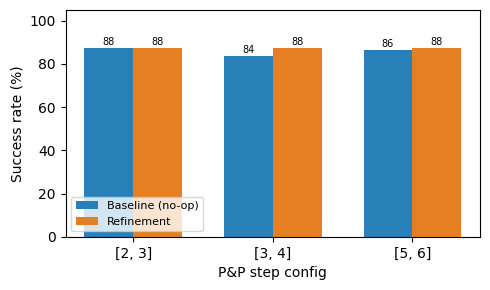

In [20]:
# Aggregate SR per step config: compare refinement vs uncertainty_only (=baseline no-op)
base = (df[df.method=='pnp_uncertainty_only']
        .groupby('pnp_step_indices')['success'].mean())
ref  = (df[df.method=='pnp_refinement']
        .groupby('pnp_step_indices')['success'].mean())

cfgs = ['[2, 3]', '[3, 4]', '[5, 6]']
base_sr = [base.get(c, np.nan)*100 for c in cfgs]
ref_sr  = [ref.get(c,  np.nan)*100 for c in cfgs]

print('Step config   baseline(no-op)   refinement   Δpp')
for c, b, r in zip(cfgs, base_sr, ref_sr):
    print(f'  {c:<10} {b:>10.1f}%     {r:>8.1f}%   {r-b:>+5.1f}')

x = np.arange(len(cfgs)); w = 0.35
fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(x - w/2, base_sr, w, label='Baseline (no-op)', color='#2980b9')
ax.bar(x + w/2, ref_sr,  w, label='Refinement',       color='#e67e22')
for xi, (b, r) in enumerate(zip(base_sr, ref_sr)):
    ax.text(xi - w/2, b + 0.5, f'{b:.0f}', ha='center', va='bottom', fontsize=7)
    ax.text(xi + w/2, r + 0.5, f'{r:.0f}', ha='center', va='bottom', fontsize=7)
ax.set_xticks(x); ax.set_xticklabels(cfgs)
ax.set_xlabel('P&P step config'); ax.set_ylabel('Success rate (%)')
ax.set_ylim(0, 105); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(os.path.join(FIGURES_DIR,'libero_config_sweep.pdf'),
                                bbox_inches='tight'); plt.show()

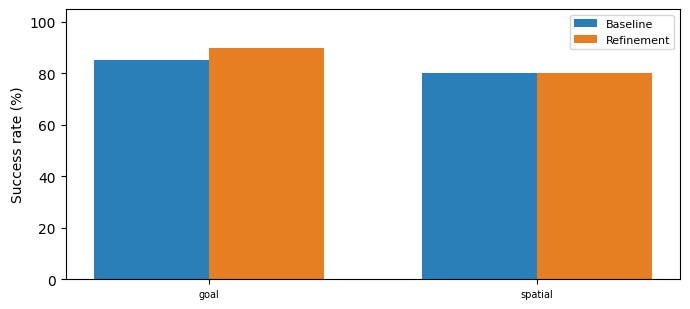

Per-suite SR change at config [3, 4]:
suite                          base    ref    Δpp
-------------------------------------------------
goal                          85.0%  90.0%  +5.0
spatial                       80.0%  80.0%  +0.0
-------------------------------------------------
AGGREGATE                     83.8%  87.5%  +3.8


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


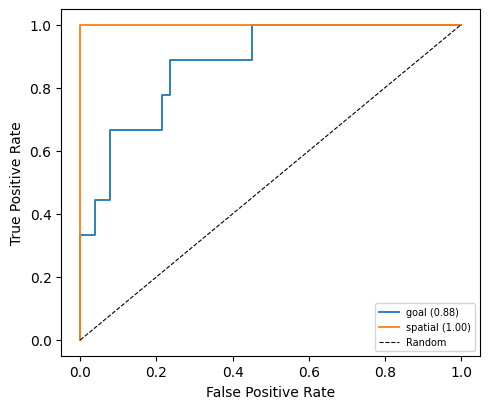

Mean within-suite detector AUC (cfg [3, 4]): 0.939


In [22]:
CFG = '[3, 4]'
sub_base = df[(df.method=='pnp_uncertainty_only') & (df.pnp_step_indices==CFG)]
sub_ref  = df[(df.method=='pnp_refinement')       & (df.pnp_step_indices==CFG)]

# ---- per-suite SR bars ----
suites = sorted(sub_base.suite.unique())
b_sr = [sub_base[sub_base.suite==s].success.mean()*100 for s in suites]
r_sr = [sub_ref [sub_ref.suite ==s].success.mean()*100 for s in suites]
x = np.arange(len(suites)); w = 0.35
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.bar(x - w/2, b_sr, w, label='Baseline', color='#2980b9')
ax.bar(x + w/2, r_sr, w, label='Refinement', color='#e67e22')
ax.set_xticks(x)
ax.set_xticklabels([s.replace('libero_','') for s in suites], rotation=0, ha='center', fontsize=7)
ax.set_ylabel('Success rate (%)'); ax.set_ylim(0,105); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(os.path.join(FIGURES_DIR,'libero_sr_cfg34.pdf'),
                                bbox_inches='tight'); plt.show()

# per-suite SR change (refinement - baseline)
print(f'Per-suite SR change at config {CFG}:')
print(f'{"suite":<28}{"base":>7}{"ref":>7}{"Δpp":>7}')
print('-'*49)
for s, b, r in zip(suites, b_sr, r_sr):
    print(f'{s.replace("libero_",""):<28}{b:>6.1f}%{r:>6.1f}%{r-b:>+6.1f}')
print('-'*49)
agg_b = sub_base.success.mean()*100
agg_r = sub_ref.success.mean()*100
print(f'{"AGGREGATE":<28}{agg_b:>6.1f}%{agg_r:>6.1f}%{agg_r-agg_b:>+6.1f}')

# ---- detector ROC per suite (uncertainty_only rows carry u_mean_episode) ----
det = sub_base.dropna(subset=['u_mean_episode','success']).copy()
det['fail'] = 1 - det['success']
from sklearn.metrics import roc_curve
fig, ax = plt.subplots(figsize=(5, 4.2))
aucs = []
for s in suites:
    g = det[det.suite==s]
    if g.fail.nunique() < 2 or len(g) < 8: continue
    a = roc_auc_score(g.fail, g.u_mean_episode); aucs.append(a)
    fpr, tpr, _ = roc_curve(g.fail, g.u_mean_episode)
    ax.plot(fpr, tpr, lw=1.3, label=f"{s.replace('libero_','')} ({a:.2f})")
ax.plot([0,1],[0,1],'k--',lw=0.8,label='Random')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.legend(fontsize=7, loc='lower right')
plt.tight_layout(); plt.savefig(os.path.join(FIGURES_DIR,'libero_roc_cfg34.pdf'),
                                bbox_inches='tight'); plt.show()
print(f'Mean within-suite detector AUC (cfg {CFG}): {np.nanmean(aucs):.3f}')